# TP2 — Binary Classification (Breast Cancer Wisconsin)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/L2Math/blob/main/session1/tp2_correction.ipynb)

## Objective

**Classification** is a supervised learning task where we predict a **category** (not a number).

In this TP, we will predict whether a breast tumor is **malignant** (cancerous) or **benign** (non-cancerous) from cell nucleus measurements.

This is **binary classification**: 2 possible outputs.

### How does it differ from regression (TP1)?

| | Regression (TP1) | Classification (TP2) |
|---|---|---|
| **Output** | Continuous number | Category (class) |
| **Example** | House price = 3.5 | Tumor = malignant |
| **Loss function** | MSE | Cross-entropy |
| **Metrics** | MSE, MAE, R² | Accuracy, Precision, Recall, F1 |

The **methodology** is the same: Explore → Visualize → Split → Train → Evaluate → Cross-validate. Only the model and metrics change.

> **Link to TP1:** Same pipeline, different task. If you understood TP1, you'll see the same pattern here.

---
## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_score, recall_score, f1_score)

---
## 2. Load & Discover the Data

The **Breast Cancer Wisconsin** dataset contains measurements of cell nuclei from breast tissue biopsies. Each sample is labeled as **malignant** (cancerous, class 0) or **benign** (non-cancerous, class 1).

30 features describe properties like radius, texture, perimeter, area, smoothness, etc.

### Exercise 1.1 — Load the dataset

Load the Breast Cancer dataset and display its shape, feature names, target names, and first rows.

**Why:** Understand what data we're working with — how many samples, how many features, what are the class names.

*Hint:* `load_breast_cancer(as_frame=True)`, `data.target_names`, `df.head()`

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame

print(f"Shape: {df.shape}")
print(f"\nTarget names: {data.target_names}")
print(f"\nFeatures: {list(data.feature_names)}")
df.head()

Shape: (569, 31)

Target names: ['malignant' 'benign']

Features: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Each tumor sample has 30 features computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. They describe characteristics of the cell nuclei.

**10 base measurements** (each computed as mean, standard error, and worst/largest):

- **Radius** – Mean distance from center to perimeter of the nucleus
- **Texture** – Standard deviation of grayscale values
- **Perimeter** – Perimeter of the nucleus
- **Area** – Area of the nucleus
- **Smoothness** – Local variation in radius lengths
- **Compactness** – Perimeter² / Area − 1
- **Concavity** – Severity of concave portions of the contour
- **Concave points** – Number of concave portions of the contour
- **Symmetry** – Symmetry of the nucleus
- **Fractal dimension** – "Coastline approximation" − 1 (complexity of the boundary)

**Three variants per measurement:**
- `mean` – Average across all nuclei in the image
- `error` – Standard error of the measurement
- `worst` – Mean of the three largest values

**Target: malignant (0) / benign (1)** – Binary classification of the tumor.

569 samples with 30 features + 1 target. Target: 0 = malignant, 1 = benign.

### Exercise 1.2 — Summary statistics

Display summary statistics for the features.

**Why:** Check the range of each feature. Are they on similar scales?

*Hint:* `df.describe()`

**Question:** Do features have similar scales? What does this suggest about preprocessing?

In [3]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


**Answer:** No — features have very different scales. For example, `mean area` ranges up to ~2500 while `mean smoothness` is around 0.05–0.16. This suggests we should scale features before training, especially for algorithms sensitive to scale like logistic regression.

### Exercise 1.3 — Check class balance

Count how many samples are malignant vs benign.

**Why:** Imbalanced classes can mislead accuracy. For example, if 95% of samples are benign, a model that always predicts "benign" gets 95% accuracy — but it's useless! We need to check class balance before trusting accuracy.

*Hint:* `y.value_counts()` and `y.value_counts(normalize=True)`

In [4]:
X = df.drop('target', axis=1)
y = df['target']

print("Class counts:")
print(y.value_counts())
print("\nClass proportions:")
print(y.value_counts(normalize=True))

Class counts:
target
1    357
0    212
Name: count, dtype: int64

Class proportions:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


About 63% benign and 37% malignant — reasonably balanced. Accuracy is a meaningful metric here (though we'll also look at precision and recall).

---
## 3. Data Visualization

In classification, visualization helps us see if classes are **separable** — can we visually tell the groups apart using certain features?

### Exercise 2.1 — Feature distribution by class

Plot the distribution of one feature (e.g. `mean radius`), colored by class.

**Why:** See if the feature distributions are different for malignant vs benign. If they overlap a lot, the feature won't help distinguish the classes.

*Hint:* `sns.histplot(data=df, x='mean radius', hue='target', kde=True)`

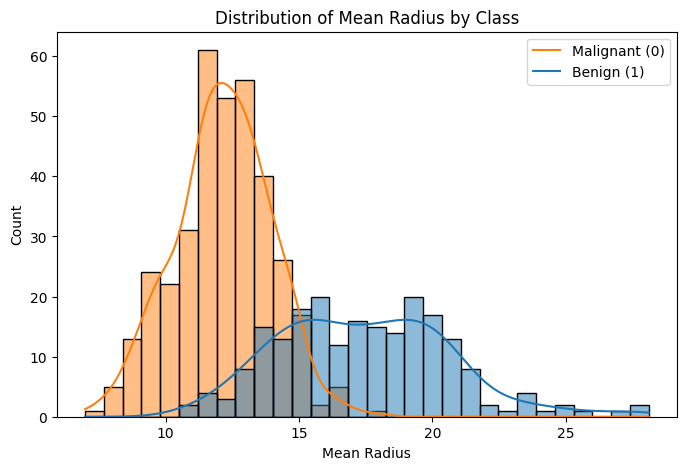

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='mean radius', hue='target', kde=True, bins=30)
plt.title('Distribution of Mean Radius by Class')
plt.xlabel('Mean Radius')
plt.legend(labels=['Malignant (0)', 'Benign (1)'])
plt.show()

The distributions are quite different — malignant tumors tend to have larger radius. This feature looks useful for classification.

### Exercise 2.2 — Scatter plot: two features colored by class

Create a scatter plot with `mean radius` vs `mean texture`, colored by class.

**Why:** See if two features together can separate the classes visually.

*Hint:* `sns.scatterplot(x='mean radius', y='mean texture', hue='target', data=df, alpha=0.6)`

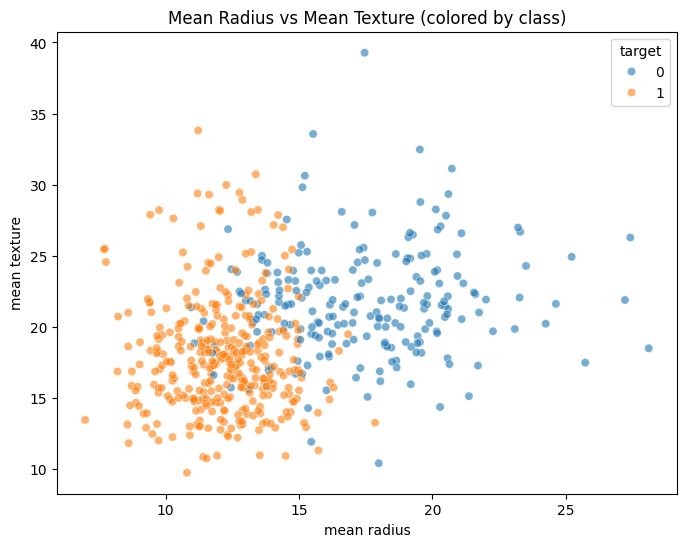

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='mean radius', y='mean texture', hue='target', data=df, alpha=0.6)
plt.title('Mean Radius vs Mean Texture (colored by class)')
plt.show()

The two classes form somewhat distinct clusters — the classes are partially separable in this 2D view.

### Exercise 2.3 — Correlation heatmap (top features)

Compute correlations with the target and display a heatmap of the top ~10 most correlated features.

**Why:** Identify which features are most related to the target — these will be most useful for the model.

*Hint:* Compute correlation with target, select top features by absolute value, then plot heatmap.

**Question:** Which features seem most useful for distinguishing malignant from benign?

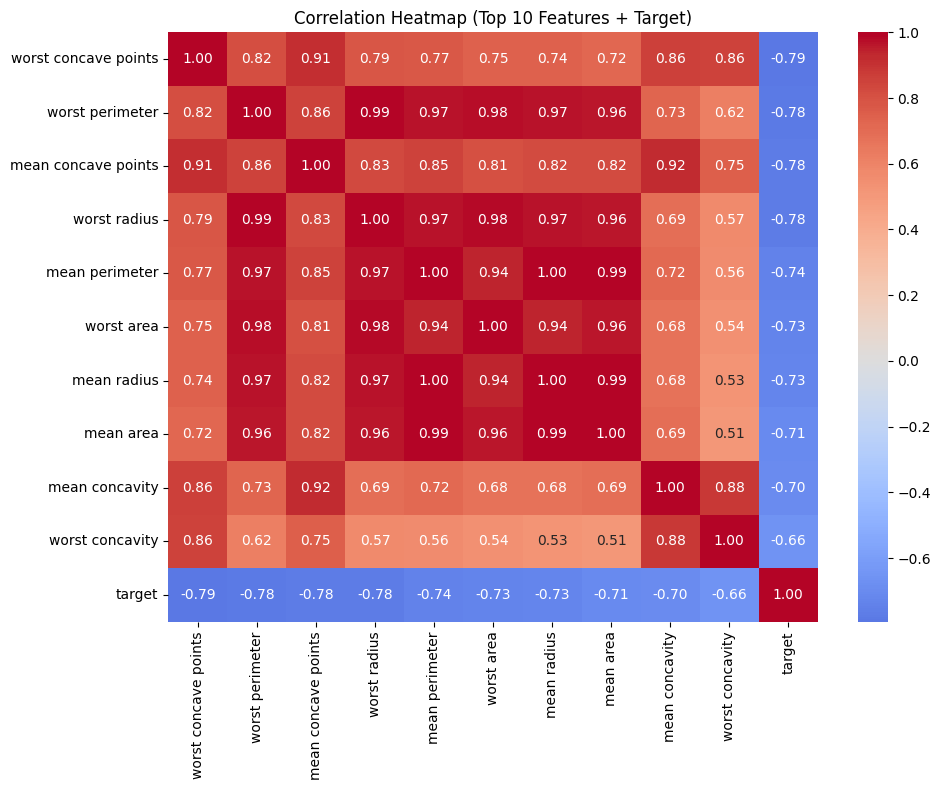

Top 10 features correlated with target:
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
Name: target, dtype: float64


In [20]:
# Compute correlation with target
correlations = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
top_features = correlations.head(10).index.tolist()

# Heatmap of top features + target
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features + ['target']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Top 10 Features + Target)')
plt.tight_layout()
plt.show()

print("Top 10 features correlated with target:")
print(correlations.head(10))

**Answer:** Features related to `worst` and `mean` measurements of concave points, perimeter, radius, and area have the strongest correlations with the target (~0.7–0.8). These geometric properties of cell nuclei are most informative for diagnosis.

---
## 4. Logistic Regression — The Classification Model

### From Regression to Classification

In regression, we predict a number directly: $\hat{y} = X\theta + b$.

For classification, we need a **probability** between 0 and 1. Logistic regression applies the **sigmoid function** to the linear combination:

$$P(y=1 | x) = \sigma(x\theta + b) = \frac{1}{1 + e^{-(x\theta + b)}}$$

The sigmoid function maps any real number to the interval $[0, 1]$:

```
  1.0 |                    ___________
      |                 /
  0.5 |- - - - - - - -/- - - - - - - - -
      |             /
  0.0 |____________/
      +------|------|------|------>
            -3      0      3       z
```

**Decision rule:** If $P(y=1|x) > 0.5$ → predict class 1 (benign), else predict class 0 (malignant).

### Loss Function: Cross-Entropy

Unlike regression (MSE), classification uses **cross-entropy** loss:

$$\mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right]$$

This measures how wrong the predicted probabilities are. It penalizes confident wrong predictions heavily.

| | Regression | Classification |
|---|---|---|
| **Model** | $\hat{y} = X\theta + b$ | $\hat{p} = \sigma(X\theta + b)$ |
| **Output** | Any real number | Probability in $[0, 1]$ |
| **Loss** | MSE | Cross-entropy |

### Exercise 3.1 — Split the data

Separate features and target, then split into train/test (80/20, `random_state=42`).

*Hint:* Same pattern as TP1.

In [8]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 455 samples
Test set: 114 samples


### Exercise 3.2 — Train a logistic regression

Train a `LogisticRegression(max_iter=5000)` model and make predictions on the test set.

*Hint:* `.fit(X_train, y_train)`, `.predict(X_test)`

In [9]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Predictions (first 10): {y_pred[:10]}")
print(f"Actual      (first 10): {y_test.values[:10]}")

Predictions (first 10): [1 0 0 1 1 0 0 0 1 1]
Actual      (first 10): [1 0 0 1 1 0 0 0 1 1]


---
## 5. Evaluation Metrics for Classification

In regression, we used MSE, MAE, R². For classification, we need different metrics.

### Accuracy

$$\text{Accuracy} = \frac{\text{correct predictions}}{\text{total predictions}}$$

Simple and intuitive, but **misleading with imbalanced classes** (e.g., 95% benign → always predict benign gives 95% accuracy).

### Confusion Matrix

A 2×2 table that shows exactly where the model succeeds and fails:

```
                    Predicted
                 Malignant  Benign
Actual Malignant    TP        FN
       Benign       FP        TN
```

- **TP** (True Positive): correctly predicted malignant
- **TN** (True Negative): correctly predicted benign
- **FP** (False Positive): predicted malignant, but actually benign (false alarm)
- **FN** (False Negative): predicted benign, but actually malignant (missed cancer!)

### Precision, Recall, F1-score

| Metric | Formula | Question it answers |
|--------|---------|--------------------|
| **Precision** | $\frac{TP}{TP + FP}$ | Of all tumors predicted malignant, how many truly are? |
| **Recall** (Sensitivity) | $\frac{TP}{TP + FN}$ | Of all truly malignant tumors, how many did we catch? |
| **F1-score** | $2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$ | Harmonic mean — balances precision and recall |

### Why Recall Matters Here

In medical diagnosis, **recall is critical** — missing a malignant tumor (false negative) is much worse than a false alarm (false positive). A false alarm leads to further testing; a missed cancer can be fatal.

### Exercise 4.1 — Compute accuracy

Compute accuracy on the test set.

*Hint:* `accuracy_score(y_test, y_pred)`

In [10]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f} ({acc*100:.1f}%)")

Accuracy: 0.9561 (95.6%)


### Exercise 4.2 — Display the confusion matrix

Display the confusion matrix with labeled classes.

**Why:** See exactly where the model makes mistakes — how many malignant tumors were missed?

*Hint:* `ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=data.target_names)`

**Question:** How many malignant tumors were missed (false negatives)? Why is this important?

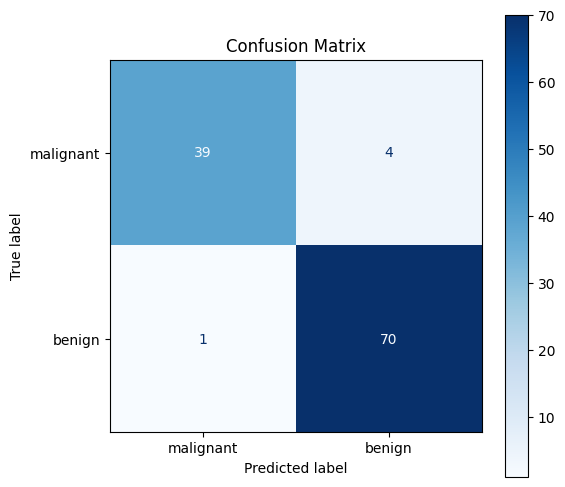

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=data.target_names, ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

**Answer:** A few malignant tumors were predicted as benign (false negatives). In a medical context, these are the most dangerous errors — a patient with cancer would be told they're healthy. This is why recall (catching all malignant cases) is crucial.

### Exercise 4.3 — Compute precision, recall, F1 manually

Extract TP, TN, FP, FN from the confusion matrix, compute precision, recall, and F1 by hand, then verify with sklearn.

**Why:** Understand the formulas by computing them yourself, then confirm with sklearn functions.

*Hint:* `cm = confusion_matrix(y_test, y_pred)` returns `[[TN, FP], [FN, TP]]` (since malignant=0, benign=1).

In [12]:
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion matrix:\n{cm}\n")

# For the "malignant" class (class 0 = positive in medical context):
# With sklearn's convention: cm[0,0]=TN for class 1, but for class 0:
# We consider malignant (0) as the positive class
TN = cm[1, 1]  # benign predicted as benign
FP = cm[1, 0]  # benign predicted as malignant
FN = cm[0, 1]  # malignant predicted as benign
TP = cm[0, 0]  # malignant predicted as malignant

print(f"TP (malignant correctly detected): {TP}")
print(f"TN (benign correctly detected): {TN}")
print(f"FP (benign predicted as malignant): {FP}")
print(f"FN (malignant predicted as benign): {FN}")

# Manual computation
precision_manual = TP / (TP + FP)
recall_manual = TP / (TP + FN)
f1_manual = 2 * precision_manual * recall_manual / (precision_manual + recall_manual)

print(f"\n--- Manual computation (malignant class) ---")
print(f"Precision: {precision_manual:.4f}")
print(f"Recall:    {recall_manual:.4f}")
print(f"F1-score:  {f1_manual:.4f}")

# Verify with sklearn (pos_label=0 since malignant is class 0)
print(f"\n--- sklearn verification ---")
print(f"Precision: {precision_score(y_test, y_pred, pos_label=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, pos_label=0):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred, pos_label=0):.4f}")

Confusion matrix:
[[39  4]
 [ 1 70]]

TP (malignant correctly detected): 39
TN (benign correctly detected): 70
FP (benign predicted as malignant): 1
FN (malignant predicted as benign): 4

--- Manual computation (malignant class) ---
Precision: 0.9750
Recall:    0.9070
F1-score:  0.9398

--- sklearn verification ---
Precision: 0.9750
Recall:    0.9070
F1-score:  0.9398


The manual and sklearn values match, confirming our understanding of the formulas.

### Exercise 4.4 — Full classification report

Display the full classification report showing metrics for both classes.

*Hint:* `print(classification_report(y_test, y_pred, target_names=data.target_names))`

In [13]:
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        43
      benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



The classification report shows precision, recall, and F1 for each class, plus the overall accuracy and macro/weighted averages.

---
## 6. Feature Scaling

### Why Scaling Matters for Logistic Regression

Logistic regression uses **gradient descent** internally to minimize the cross-entropy loss. When features have very different scales, the loss surface becomes elongated, and gradient descent converges slowly or poorly.

Same `StandardScaler` approach as TP1:

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

**Remember:** Fit on train, transform both!

### Exercise 5.1 — Scale features and retrain

Scale features with `StandardScaler`, retrain the model, and compare accuracy and confusion matrix.

*Hint:* Same pattern as TP1 — `scaler.fit_transform(X_train)`, `scaler.transform(X_test)`.

**Question:** Did scaling improve results? Why or why not?

Accuracy (without scaling): 0.9561
Accuracy (with scaling):    0.9737

Confusion matrix (with scaling):


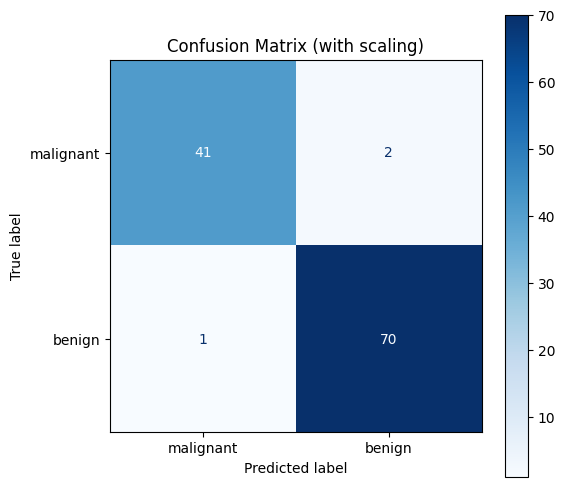

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LogisticRegression(max_iter=5000)
model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

print(f"Accuracy (without scaling): {accuracy_score(y_test, y_pred):.4f}")
print(f"Accuracy (with scaling):    {accuracy_score(y_test, y_pred_scaled):.4f}")

print("\nConfusion matrix (with scaling):")
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_scaled, display_labels=data.target_names, ax=ax, cmap='Blues')
plt.title('Confusion Matrix (with scaling)')
plt.show()

**Answer:** Scaling may improve results slightly. Logistic regression uses gradient descent, and features with different scales make optimization harder. With `max_iter=5000`, the model may already converge, but scaling helps it converge faster and more reliably.

---
## 7. Cross-Validation

Same principle as TP1 — rotate the test set across K folds for a more robust performance estimate.

For classification, we use `scoring='accuracy'`.

### Exercise 6.1 — 5-fold cross-validation

Run 5-fold cross-validation and report accuracy mean ± std.

*Hint:* `cross_val_score(LogisticRegression(max_iter=5000), X, y, cv=5, scoring='accuracy')`

**Question:** Is the model stable across folds?

In [15]:
scores = cross_val_score(LogisticRegression(max_iter=5000), X, y, cv=5, scoring='accuracy')

print(f"Accuracy scores per fold: {scores}")
print(f"Accuracy mean: {scores.mean():.4f}")
print(f"Accuracy std:  {scores.std():.4f}")
print(f"\nAccuracy = {scores.mean():.4f} ± {scores.std():.4f}")

Accuracy scores per fold: [0.93859649 0.94736842 0.98245614 0.92982456 0.95575221]
Accuracy mean: 0.9508
Accuracy std:  0.0180

Accuracy = 0.9508 ± 0.0180


**Answer:** The standard deviation is small (~0.02), indicating the model performs consistently across different data splits. The model is stable.

---
## 8. Summary & Comparison with Regression

### Regression vs Classification

| | Regression (TP1) | Classification (TP2) |
|---|---|---|
| **Task** | Predict a continuous value | Predict a category |
| **Output** | Real number ($\hat{y} \in \mathbb{R}$) | Class label (0 or 1) |
| **Model** | Linear Regression | Logistic Regression |
| **Loss function** | MSE: $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Cross-entropy |
| **Key metrics** | MSE, MAE, R² | Accuracy, Precision, Recall, F1 |

### Key Takeaway

The **methodology** is the same in both cases:

1. **Explore** → Understand your data
2. **Visualize** → See patterns and relationships
3. **Split** → Train/test for honest evaluation
4. **Train** → Fit the appropriate model
5. **Evaluate** → Use the right metrics for your task
6. **Cross-validate** → Get a robust performance estimate

Only the **model** and **metrics** change depending on whether the task is regression or classification.

### Next Sessions

- More models (Decision Trees, Random Forests, SVM, KNN)
- More preprocessing techniques
- Ensemble methods